In [75]:
import numpy as np
import pandas as pd
import torch
import os, sys
sys.path.append(os.path.realpath('./src/'))

import time
import matplotlib.pyplot as plt
import matplotlib
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon, Ellipse
from smallestEllipse import *

from utilFuncs import to_np, to_torch
from materialEncoder import MaterialEncoder


import scipy as sp




In [76]:
def preprocessData():
    # Load your data
    df = pd.read_excel('./ashby_from_granta_selection3.xlsx')

    # Keep track of 'family' 
    dataIdentifier = {
    "material": df["material"],     # or df["material"] depending on your sheet
    "family": df["Family"],        
    'classID':df['index']
}


    # Select the properties you want to model (features)
    feature_columns = ['rho', 'sig_y']
    trainInfo = np.log10(df[feature_columns].to_numpy())

    # Normalize to [0, 1]
    dataScaleMax = torch.tensor(np.max(trainInfo, axis=0))
    dataScaleMin = torch.tensor(np.min(trainInfo, axis=0))
    normalizedData = (torch.tensor(trainInfo) - dataScaleMin) / (dataScaleMax - dataScaleMin)
    trainingData = normalizedData.clone().float()

    # Create dataInfo for reference
    dataInfo = {
        'rho': {'idx': 0, 'scaleMin': dataScaleMin[0], 'scaleMax': dataScaleMax[0]},
        'E':   {'idx': 1, 'scaleMin': dataScaleMin[1], 'scaleMax': dataScaleMax[1]},
    }

    return trainingData, dataInfo, dataIdentifier, trainInfo

trainingData, dataInfo, dataIdentifier, trainInfo = preprocessData()
numMaterialsInTrainingData, numFeatures = trainingData.shape


In [77]:
latentDim, hiddenDim = 2, 250
numEpochs = 10000
klFactor = 4.5e-5
learningRate = 2e-3
savedNet = './data/vaeNet.nt'
vaeSettings = {'encoder':{'inputDim':numFeatures, 'hiddenDim':hiddenDim,\
                                          'latentDim':latentDim},\
               'decoder':{'latentDim':latentDim, 'hiddenDim':hiddenDim,\
                                          'outputDim':numFeatures}}
materialEncoder = MaterialEncoder(trainingData, dataInfo, dataIdentifier, vaeSettings)
start = time.perf_counter()
convgHistory = materialEncoder.trainAutoencoder(numEpochs, klFactor, savedNet, learningRate)
print('training time : {:.2F} '.format(time.perf_counter() - start))

cpu
Iter 0 reconLoss 5.05E+00 klLoss 1.69E-03 loss 5.05E+00
Iter 500 reconLoss 1.01E-02 klLoss 1.09E-02 loss 2.10E-02
Iter 1000 reconLoss 3.46E-03 klLoss 9.80E-03 loss 1.33E-02
Iter 1500 reconLoss 2.13E-03 klLoss 9.29E-03 loss 1.14E-02
Iter 2000 reconLoss 1.66E-03 klLoss 8.92E-03 loss 1.06E-02
Iter 2500 reconLoss 1.31E-03 klLoss 8.67E-03 loss 9.97E-03
Iter 3000 reconLoss 2.17E-03 klLoss 8.57E-03 loss 1.07E-02
Iter 3500 reconLoss 1.55E-03 klLoss 8.28E-03 loss 9.83E-03
Iter 4000 reconLoss 1.32E-03 klLoss 8.21E-03 loss 9.53E-03
Iter 4500 reconLoss 1.71E-03 klLoss 8.06E-03 loss 9.77E-03
Iter 5000 reconLoss 1.31E-03 klLoss 7.91E-03 loss 9.22E-03
Iter 5500 reconLoss 1.04E-03 klLoss 7.76E-03 loss 8.80E-03
Iter 6000 reconLoss 1.45E-03 klLoss 7.74E-03 loss 9.19E-03
Iter 6500 reconLoss 1.20E-03 klLoss 7.42E-03 loss 8.61E-03
Iter 7000 reconLoss 2.30E-03 klLoss 7.49E-03 loss 9.79E-03
Iter 7500 reconLoss 1.47E-03 klLoss 7.35E-03 loss 8.83E-03
Iter 8000 reconLoss 2.26E-03 klLoss 7.23E-03 loss 9.49E-

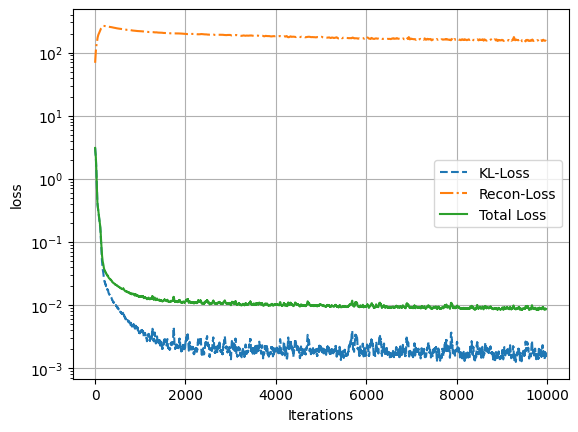

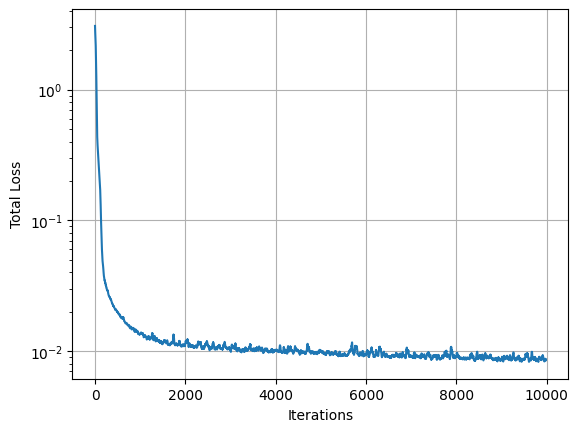

In [78]:
def plotConvergence(convg):
  plt.figure()
  strokes = ['--', '-.', '-', ':']
  for ctr, key in enumerate(convg):
    y = torch.as_tensor(convg[key]).detach().numpy()
    y_mvavg = np.convolve(y, np.ones(20), 'valid') / 20.
    plt.semilogy(y_mvavg, strokes[ctr], label = str(key))
    plt.xlabel('Iterations')
    plt.ylabel(str(key))
    plt.grid('True')
    plt.legend(labels={'KL-Loss','Recon-Loss','Total Loss'})
    # plt.legend('ReconLoss','KL-Loss','TotalLoss')
    plt.savefig('./figures/convergence.pdf',bbox_inches='tight')

plotConvergence(convgHistory)


def plotLoss(convg):
  plt.figure()
  y = torch.as_tensor(convg['loss']).detach().numpy()
  y_mvavg = np.convolve(y, np.ones(20), 'valid') / 20.
  plt.semilogy(y_mvavg, '-', label = 'Total Loss')
  plt.xlabel('Iterations')
  plt.ylabel('Total Loss')
  plt.grid('True')
  # plt.legend(labels={'Total Loss'})

plotLoss(convgHistory)



In [79]:
props = {'rho', 'E'}

def unnormalize(val, minval, maxval):
    return 10.**(minval + (maxval - minval) * val)

def decodeAll():
    vae = materialEncoder.vaeNet
    decoded = vae.decoder(vae.encoder.z)
    matProp = {}
    for k in props:
        idx = materialEncoder.dataInfo[k]['idx']
        scaleMax = materialEncoder.dataInfo[k]['scaleMax']
        scaleMin = materialEncoder.dataInfo[k]['scaleMin']
        matProp[k] = unnormalize(decoded[:, idx], scaleMin, scaleMax)
    return matProp

matProp = decodeAll()

print('\n----- Per-Material Reconstruction Table (First 10 Entries) -----\n')
header = f"{'Index':<5} {'Family':<20}"
for p in props:
    header += f"{p + ' (True)':>15} {p + ' (Recon)':>15} {p + ' %Err':>10}"
print(header)
print('-' * len(header))

maxError = {p: -1e10 for p in props}

# Limiting to the first 10 materials
num_entries_to_show = 10  # Change this to show more/less entries

for i in range(trainInfo.shape[0]):  # Only loop through the first 10 materials
    family = dataIdentifier['material'][i]
    row = f"{i:<5} {family:<20}"
    for p in props:
        idx = materialEncoder.dataInfo[p]['idx']
        true_val = 10**trainInfo[i, idx]
        recon_val = matProp[p][i].item()
        err_pct = abs(100 * (true_val - recon_val) / true_val)
        row += f"{true_val:15.3e} {recon_val:15.3e} {err_pct:10.2f}"

        # Update max error
        if err_pct > maxError[p]:
            maxError[p] = err_pct
    if i < num_entries_to_show:  # Only print the first 10 materials        
        print(row)

print('\n----- MAX Error per Property (%) -----')
for p in props:
    print(f"{p:<10}: {maxError[p]:.2f}")



----- Per-Material Reconstruction Table (First 10 Entries) -----

Index Family                     E (True)       E (Recon)     E %Err     rho (True)     rho (Recon)   rho %Err
--------------------------------------------------------------------------------------------------------------
0     Natural rubber            1.650e-03       1.741e-03       5.51      9.500e+02       9.784e+02       2.99
1     Polyurethane              1.625e-02       1.479e-02       8.97      1.200e+03       1.218e+03       1.50
2     Al/SiC composite          9.050e+01       9.085e+01       0.39      2.780e+03       2.905e+03       4.49
3     CFRP epoxy                5.490e+01       5.084e+01       7.40      1.565e+03       1.595e+03       1.90
4     GFRP epoxy                2.140e+01       2.370e+01      10.75      1.860e+03       1.932e+03       3.85
5     Flexible polymer foam      2.000e-03       1.884e-03       5.82      5.400e+01       5.412e+01       0.23
6     Rigid polymer foam        3.400e-01   

In [80]:
merr = torch.tensor([0.])
meanError = {'rho':merr,'E':merr}

for i in range(trainInfo.shape[0]):
  # if(i in matidxs): #
  #   print(f"\n {dataIdentifier['name'][i]} \t ", end = '')
  for p in props:
    idx = materialEncoder.dataInfo[p]['idx']
    trueData = 10**trainInfo[i,idx]
    reconData = matProp[p][i]
    err = torch.abs(100.*(trueData - reconData)/trueData).cpu()
    err = err.reshape((1,) + err.shape)
    meanError[p] = torch.cat((meanError[p],err),0)
    # meanError[p] = torch.cat([meanError[p],err],0)

print('\n \t -----Mean Error %----- \t ', end = '\n')
for p in props:
    print(p, end = '\t')
    print('\t {:.1F} \t'.format(torch.mean(meanError[p])), end='\n')


 	 -----Mean Error %----- 	 
E		 5.7 	
rho		 2.8 	


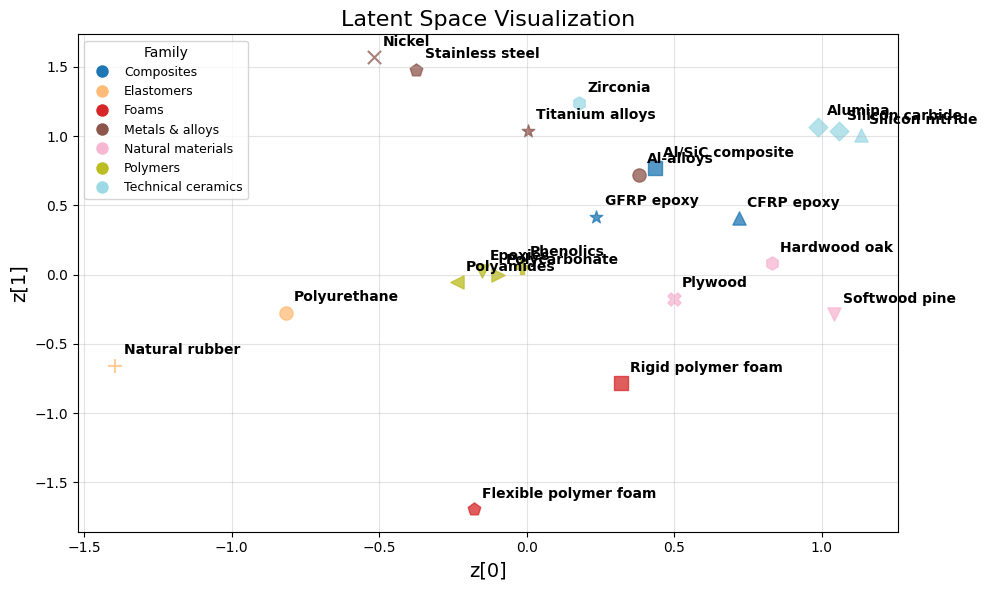

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial import ConvexHull
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

def plotLatent(
    autoencoder, dataIdentifier,
    plotHull=False, plotEllipse=False,
    label_points=True,
    label_mode="centroid",          # "centroid" or "each"
    text_offset=(6, 6),
    legend_mode="family",           # "family" or "material"
    save_path='./figures/latent_space_plot.png'
):
    # latent points
    z = autoencoder.encoder.z.to('cpu').detach().numpy()

    # columns
    materials = np.asarray(dataIdentifier["material"])
    families  = np.asarray(dataIdentifier["family"])

    unique_fams = np.unique(families)
    num_fams = len(unique_fams)

    # one color per family
    fam_colors = cm.tab20(np.linspace(0, 1, max(num_fams, 3)))
    fam_to_color = {fam: fam_colors[i % len(fam_colors)] for i, fam in enumerate(unique_fams)}

    # optional: markers by material (so you can still distinguish materials inside same family)
    unique_mats = np.unique(materials)
    mrkrSet = ['o','s','D','^','v','p','*','h','+','x','P','X','<','>']
    mat_to_marker = {m: mrkrSet[i % len(mrkrSet)] for i, m in enumerate(unique_mats)}

    plt.figure(figsize=(10, 6))

    # Plot by MATERIAL (keeps separate markers), but color comes from FAMILY
    for mat in unique_mats:
        idxs = np.where(materials == mat)[0]
        pts = z[idxs, :]

        fam = families[idxs[0]]
        c = fam_to_color[fam]
        mk = mat_to_marker[mat]

        plt.scatter(
            pts[:, 0], pts[:, 1],
            c=[c], marker=mk, alpha=0.75, s=90,
            label=str(mat) if legend_mode == "material" else None
        )

        # labels
        if label_points:
            if label_mode == "each":
                for p in pts:
                    plt.annotate(
                        str(mat), (p[0], p[1]),
                        textcoords="offset points", xytext=text_offset,
                        ha="left", va="bottom", fontsize=9
                    )
            else:
                mean = np.mean(pts, axis=0)
                plt.annotate(
                    str(mat), (mean[0], mean[1]),
                    textcoords="offset points", xytext=text_offset,
                    ha="left", va="bottom", fontsize=10, fontweight="bold"
                )

        # optional hull/ellipse PER MATERIAL (you can change to per FAMILY if you prefer)
        if plotHull and len(pts) >= 3:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                plt.plot(pts[simplex, 0], pts[simplex, 1], '-', linewidth=0.6, alpha=0.6, color=c)

        if plotEllipse and len(pts) > 2:
            cov = np.cov(pts.T)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
            width, height = 2 * np.sqrt(np.maximum(vals, 1e-12))
            mean = np.mean(pts, axis=0)

            ellipse = Ellipse(
                xy=mean, width=width, height=height, angle=angle,
                edgecolor=c, fc='None', lw=1.5, ls='--', alpha=0.9
            )
            plt.gca().add_patch(ellipse)

    # Legend: families only (recommended, otherwise it becomes huge)
    if legend_mode == "family":
        handles = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=fam_to_color[f], markersize=10,
                   label=str(f))
            for f in unique_fams
        ]
        plt.legend(handles=handles, title="Family", fontsize=9)
    else:
        plt.legend(fontsize=8)

    plt.xlabel('z[0]', fontsize=14)
    plt.ylabel('z[1]', fontsize=14)
    plt.title('Latent Space Visualization', fontsize=16)
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plotLatent(
    materialEncoder.vaeNet,
    dataIdentifier,
    plotHull=False,
    plotEllipse=False,
    label_points=True,
    label_mode="centroid",
    legend_mode="family",
    save_path="./figures/latent_family_colors.png"
)


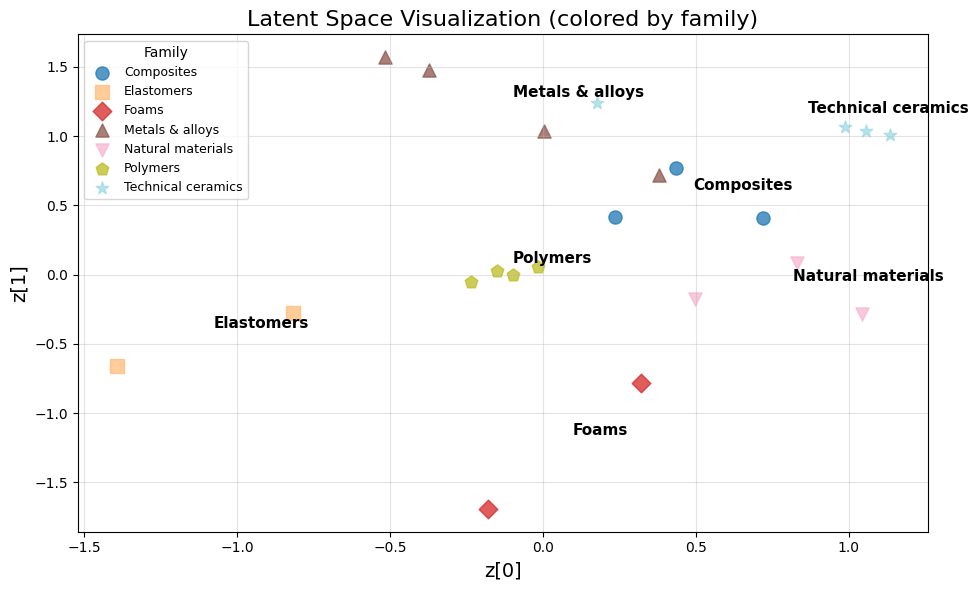

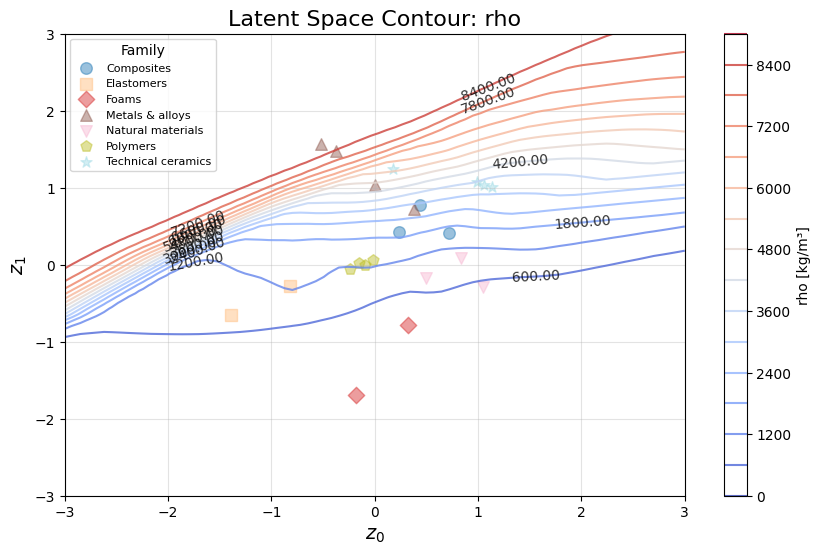

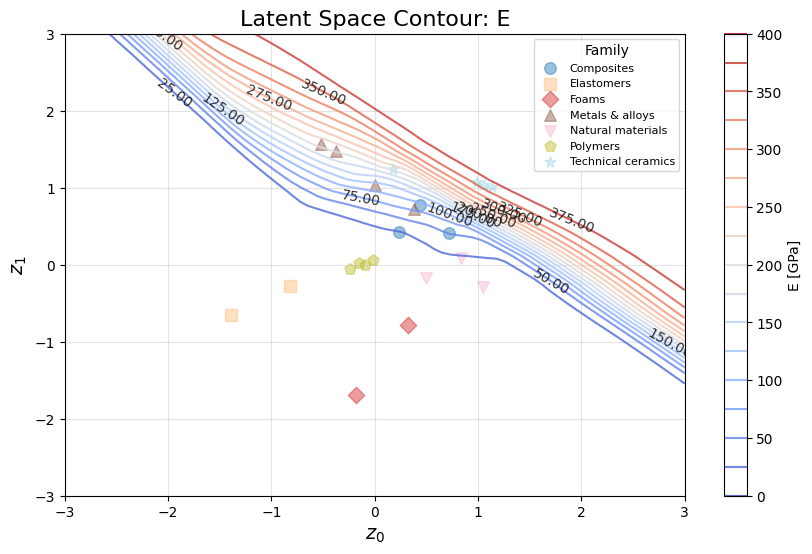

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial import ConvexHull
from matplotlib.patches import Ellipse

# ----------------------------
# 1) Latent scatter by FAMILY
# ----------------------------
def plotLatent(
    autoencoder, dataIdentifier,
    plotHull=False, plotEllipse=False,
    label_points=True,
    label_mode="centroid",        # "centroid" or "each"
    text_offset=(6, 6),
    save_path='./figures/latent_space_plot_7.png'
):
    z = autoencoder.encoder.z.to('cpu').detach().numpy()  # (N, latent_dim)

    # --- pull arrays ---
    if hasattr(dataIdentifier, "loc"):  # pandas DataFrame
        materials_col = dataIdentifier["material"].to_numpy()
        family_col    = dataIdentifier["family"].to_numpy()
    else:
        materials_col = np.asarray(dataIdentifier["material"])
        family_col    = np.asarray(dataIdentifier["family"])

    families = np.unique(family_col)
    num_fam = len(families)

    # one color per family
    fam_colors = cm.tab20(np.linspace(0, 1, max(num_fam, 3)))
    fam_to_color = {fam: fam_colors[i % len(fam_colors)] for i, fam in enumerate(families)}

    # marker set (optional, one marker per family)
    mrkrSet = ['o', 's', 'D', '^', 'v', 'p', '*', 'h', '+', 'x']

    plt.figure(figsize=(10, 6))

    # Plot each family as a group (same color)
    for i, fam in enumerate(families):
        idxs = np.where(family_col == fam)[0]
        points = z[idxs, :]

        plt.scatter(
            points[:, 0], points[:, 1],
            c=[fam_to_color[fam]],
            marker=mrkrSet[i % len(mrkrSet)],
            label=str(fam),
            alpha=0.75,
            s=90
        )

        # --- labels ---
        if label_points:
            if label_mode == "each":
                for k in idxs:
                    plt.annotate(
                        str(materials_col[k]), (z[k, 0], z[k, 1]),
                        textcoords="offset points",
                        xytext=text_offset,
                        ha="left", va="bottom", fontsize=9
                    )
            else:
                mean = np.mean(points, axis=0)
                plt.annotate(
                    str(fam), (mean[0], mean[1]),
                    textcoords="offset points",
                    xytext=text_offset,
                    ha="left", va="bottom",
                    fontsize=11, fontweight="bold"
                )

        # --- optional hull/ellipse per family ---
        if plotHull and len(points) >= 3:
            hull = ConvexHull(points[:, [0, 1]])
            for simplex in hull.simplices:
                plt.plot(points[simplex, 0], points[simplex, 1],
                         '-', linewidth=0.9, alpha=0.6, color=fam_to_color[fam])

        if plotEllipse and len(points) > 2:
            cov = np.cov(points[:, [0, 1]].T)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
            width, height = 2 * np.sqrt(np.maximum(vals, 1e-12))
            mean = np.mean(points[:, [0, 1]], axis=0)

            ellipse = Ellipse(
                xy=mean, width=width, height=height, angle=angle,
                edgecolor=fam_to_color[fam], fc='None',
                lw=2.0, ls='--', alpha=0.9
            )
            plt.gca().add_patch(ellipse)

    plt.xlabel('z[0]', fontsize=14)
    plt.ylabel('z[1]', fontsize=14)
    plt.title('Latent Space Visualization (colored by family)', fontsize=16)
    plt.grid(True, alpha=0.35)
    plt.legend(title="Family", fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, format='png', dpi=300)
    plt.show()

# ------------------------------------------
# 2) Property contour + overlay by FAMILY
# ------------------------------------------
def plotLatentProperty(
    autoencoder, dataInfo, dataIdentifier,
    property_name='rho', ltnt1=0, ltnt2=1,
    grid_size=80, zmin=-3, zmax=3, contour_levels=15,
    plotHull=False, plotEllipse=True,
    save_path=None, show_plot=True
):
    import torch  # needed here because you use torch in this function

    # Helper conversions (use yours if already defined elsewhere)
    def to_torch(x):
        return torch.tensor(x, dtype=torch.float32)

    def to_np(x):
        return x.detach().cpu().numpy()

    # Prepare latent grid
    X, Y = np.meshgrid(np.linspace(zmin, zmax, grid_size), np.linspace(zmin, zmax, grid_size))
    Z = torch.zeros((grid_size**2, autoencoder.encoder.z.shape[1]), dtype=torch.float32).to('cpu')
    Z[:, ltnt1], Z[:, ltnt2] = to_torch(X.reshape(-1)), to_torch(Y.reshape(-1))

    # Decode property
    with torch.no_grad():
        decoded = autoencoder.decoder(Z)
    decoded_np = to_np(decoded)

    # Property scaling
    idx = dataInfo[property_name]['idx']
    scaleMin = float(dataInfo[property_name]['scaleMin'])
    scaleMax = float(dataInfo[property_name]['scaleMax'])
    prop_vals = 10. ** (scaleMin + decoded_np[:, idx] * (scaleMax - scaleMin))

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Contour plot of the property
    property_units = {'rho': 'kg/m³', 'E': 'GPa'}
    prop_grid = prop_vals.reshape((grid_size, grid_size))
    contour = ax.contour(X, Y, prop_grid, levels=contour_levels, cmap='coolwarm', alpha=0.8)
    plt.clabel(contour, inline=False, fontsize=10, fmt='%0.2f', colors='black')
    cbar = plt.colorbar(contour, ax=ax)
    unit = property_units.get(property_name, '')
    cbar.set_label(f'{property_name} [{unit}]')

    # --- overlay latent points colored by FAMILY ---
    z_pts = autoencoder.encoder.z.to('cpu').detach().numpy()

    if hasattr(dataIdentifier, "loc"):  # pandas DataFrame
        materials_col = dataIdentifier["material"].to_numpy()
        family_col    = dataIdentifier["family"].to_numpy()
    else:
        materials_col = np.asarray(dataIdentifier["material"])
        family_col    = np.asarray(dataIdentifier["family"])

    families = np.unique(family_col)
    fam_colors = cm.tab20(np.linspace(0, 1, max(len(families), 3)))
    fam_to_color = {fam: fam_colors[i % len(fam_colors)] for i, fam in enumerate(families)}

    mrkrSet = ['o', 's', 'D', '^', 'v', 'p', '*', 'h', '+', 'x']

    for i, fam in enumerate(families):
        idxs = np.where(family_col == fam)[0]
        pts = z_pts[idxs, :]

        ax.scatter(
            pts[:, ltnt1], pts[:, ltnt2],
            c=[fam_to_color[fam]],
            marker=mrkrSet[i % len(mrkrSet)],
            label=str(fam),
            alpha=0.45,
            s=70
        )

        if plotHull and len(pts) >= 3:
            hull = ConvexHull(pts[:, [ltnt1, ltnt2]])
            for simplex in hull.simplices:
                ax.plot(
                    pts[simplex, ltnt1], pts[simplex, ltnt2],
                    linewidth=0.8, alpha=0.7, color=fam_to_color[fam]
                )

        if plotEllipse and len(pts) > 2:
            cov = np.cov(pts[:, [ltnt1, ltnt2]].T)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
            width, height = 2 * np.sqrt(np.maximum(vals, 1e-12))
            mean = np.mean(pts[:, [ltnt1, ltnt2]], axis=0)
            ellipse = Ellipse(
                xy=mean, width=width, height=height, angle=angle,
                edgecolor=fam_to_color[fam], fc='None',
                lw=1.5, ls='--', alpha=0.9
            )
            ax.add_patch(ellipse)

    ax.set_xlabel(f'$z_{ltnt1}$', fontsize=14)
    ax.set_ylabel(f'$z_{ltnt2}$', fontsize=14)
    ax.set_title(f'Latent Space Contour: {property_name}', fontsize=16)
    ax.legend(title="Family", fontsize=8)
    ax.grid(True, alpha=0.35)

    # Save and/or show
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close()


# -----------------------
# Example usage
# -----------------------
plotLatent(
    autoencoder=materialEncoder.vaeNet,
    dataIdentifier=dataIdentifier,
    plotHull=False,
    plotEllipse=False,
    label_points=True,
    label_mode="centroid",
    save_path='./figures/latent_space_plot_7.png'
)

plotLatentProperty(
    autoencoder=materialEncoder.vaeNet,
    dataInfo=materialEncoder.dataInfo,
    dataIdentifier=dataIdentifier,
    property_name='rho',
    ltnt1=0,
    ltnt2=1,
    plotHull=False,
    plotEllipse=False,
    save_path='./figures/rho_eff_latentField_7.pdf'
)

plotLatentProperty(
    autoencoder=materialEncoder.vaeNet,
    dataInfo=materialEncoder.dataInfo,
    dataIdentifier=dataIdentifier,
    property_name='E',
    ltnt1=0,
    ltnt2=1,
    plotHull=False,
    plotEllipse=False,
    save_path='./figures/E_latentField_7.pdf'
)



In [83]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# === VAE handles ===
vae = materialEncoder.vaeNet
decoder = vae.decoder

# === Training latent codes ===
z_train = vae.encoder.z.detach()
latent_dim = z_train.shape[1]

z_min = z_train.min(dim=0)[0]
z_max = z_train.max(dim=0)[0]

z_mean = z_train.mean(dim=0, keepdim=True)
z_std  = z_train.std(dim=0, keepdim=True) + 1e-6

# === utilities ===
def unnormalize(val, minval, maxval):
    return 10.0 ** (minval + (maxval - minval) * val)

def decode_rho_E(z):
    decoded = decoder(z).squeeze()

    rho = unnormalize(
        decoded[dataInfo['rho']['idx']],
        dataInfo['rho']['scaleMin'],
        dataInfo['rho']['scaleMax']
    )

    E = unnormalize(
        decoded[dataInfo['E']['idx']],
        dataInfo['E']['scaleMin'],
        dataInfo['E']['scaleMax']
    )

    return rho, E, decoded

# ============================================================
# === Beam Ashby index: M = sqrt(E) / rho  (maximize)
# We optimize log(M) for numerical stability:
#   log M = 0.5*log(E) - log(rho)
# ============================================================
def log_ashby_index_beam(rho, E, eps=1e-12):
    return 0.5 * torch.log(E + eps) - torch.log(rho + eps)

def latent_prior(z):
    return torch.sum(((z - z_mean) / z_std) ** 2)

# === single-objective optimization ===
def optimize_ashby_beam(
    steps=600,
    lr=0.05,
    lambda_prior=0.10,
    clamp=True,
    return_path=False,
    z0=None,              # user-provided start (array-like of length latent_dim or shape (1, latent_dim))
    clamp_init=True,      # clamp the provided initial point too
    tol=1e-6              # stopping criterion on ||z_{k+1}-z_k||
):
    # --- init z0 (keep original behavior if z0 is None) ---
    if z0 is None:
        z0_t = z_mean + z_std * torch.randn(1, latent_dim, device=z_train.device, dtype=z_train.dtype)
    else:
        z0_t = torch.as_tensor(z0, device=z_train.device, dtype=z_train.dtype)
        if z0_t.ndim == 1:
            z0_t = z0_t.unsqueeze(0)  # (1, latent_dim)
        if z0_t.shape != (1, latent_dim):
            raise ValueError(f"z0 must have shape (latent_dim,) or (1, latent_dim); got {tuple(z0_t.shape)}")

    if clamp and clamp_init:
        with torch.no_grad():
            z0_t = torch.max(torch.min(z0_t, z_max), z_min)

    z = torch.nn.Parameter(z0_t.clone())
    optimizer = torch.optim.Adam([z], lr=lr)

    z_path = []
    M_path = []

    # record the true starting point BEFORE the first update
    if return_path:
        with torch.no_grad():
            rho0, E0, _ = decode_rho_E(z)
            M0 = torch.sqrt(E0) / rho0
            z_path.append(z.detach().cpu().numpy().copy()[0])
            M_path.append(float(M0.detach().cpu()))

    # optimization loop with stopping criterion
    for _ in range(steps):
        z_prev = z.detach().clone()

        optimizer.zero_grad()

        rho, E, _ = decode_rho_E(z)
        logM = log_ashby_index_beam(rho, E)

        loss = -logM + lambda_prior * latent_prior(z)
        loss.backward()
        optimizer.step()

        if clamp:
            with torch.no_grad():
                z.data = torch.max(torch.min(z, z_max), z_min)

        with torch.no_grad():
            if torch.norm(z - z_prev) < tol:
                break

        if return_path:
            with torch.no_grad():
                z_path.append(z.detach().cpu().numpy().copy()[0])
                M_path.append(float((torch.sqrt(E) / rho).detach().cpu()))

    with torch.no_grad():
        rho, E, _ = decode_rho_E(z)
        M = torch.sqrt(E) / rho

    if return_path:
        return (
            z.detach().cpu().numpy(), float(rho), float(E), float(M),
            np.asarray(z_path), np.asarray(M_path)
        )
    else:
        return z.detach().cpu().numpy(), float(rho), float(E), float(M)


# ======================================================================
# === multi-start search (CHOOSE YOUR STARTS HERE) =======================
# ======================================================================

results = []

import numpy as np

z_vals = np.linspace(-1.5, 1.5, 7)   # [-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5]
z_vals_2 = np.linspace(-1, 1, 5)   # [-1.0, -0.5, 0, 0.5, 1.0]

z0_list = [[z1, z2] for z1 in z_vals_2 for z2 in z_vals]
print(z0_list)
print("Number of start points:", len(z0_list))

print(f"Running Ashby optimization (sqrt(E)/rho) with {len(z0_list)} user-defined starts...")
for z0 in z0_list:
    z, rho, E, M, z_path, M_path = optimize_ashby_beam(return_path=True, z0=z0)
    results.append({"z0": z0, "z": z[0], "rho": rho, "E": E, "M": M, "z_path": z_path, "M_path": M_path})

# === select best ===
best = max(results, key=lambda r: r["M"])

print("\n=== Best material (sqrt(E) / rho) ===")
print(f"start z0 = {best['z0']}")
print(f"rho = {best['rho']:.1f} kg/m³")
print(f"E   = {best['E']:.4f} GPa")
print(f"M   = {best['M']:.6g} (sqrt(E)/rho)")

[[np.float64(-1.0), np.float64(-1.5)], [np.float64(-1.0), np.float64(-1.0)], [np.float64(-1.0), np.float64(-0.5)], [np.float64(-1.0), np.float64(0.0)], [np.float64(-1.0), np.float64(0.5)], [np.float64(-1.0), np.float64(1.0)], [np.float64(-1.0), np.float64(1.5)], [np.float64(-0.5), np.float64(-1.5)], [np.float64(-0.5), np.float64(-1.0)], [np.float64(-0.5), np.float64(-0.5)], [np.float64(-0.5), np.float64(0.0)], [np.float64(-0.5), np.float64(0.5)], [np.float64(-0.5), np.float64(1.0)], [np.float64(-0.5), np.float64(1.5)], [np.float64(0.0), np.float64(-1.5)], [np.float64(0.0), np.float64(-1.0)], [np.float64(0.0), np.float64(-0.5)], [np.float64(0.0), np.float64(0.0)], [np.float64(0.0), np.float64(0.5)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.5)], [np.float64(0.5), np.float64(-1.5)], [np.float64(0.5), np.float64(-1.0)], [np.float64(0.5), np.float64(-0.5)], [np.float64(0.5), np.float64(0.0)], [np.float64(0.5), np.float64(0.5)], [np.float64(0.5), np.float64(1.0)], [

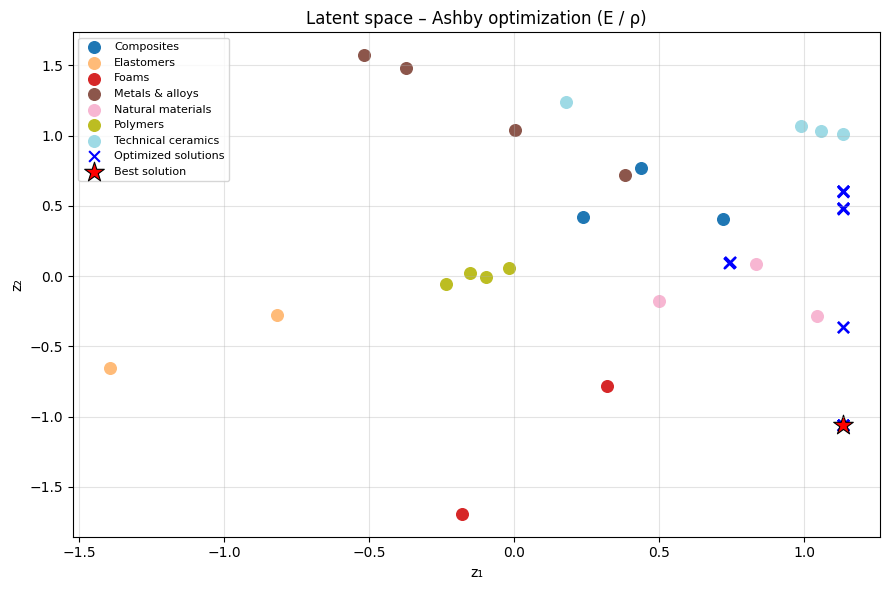

In [84]:
# ============================================================
# === latent space plot (training colored by FAMILY) + opt ====
# ============================================================

# Training arrays
z_real = z_train.cpu().numpy()

# Pull family/material from dataIdentifier
if hasattr(dataIdentifier, "loc"):  # pandas DataFrame
    family_train = dataIdentifier["family"].to_numpy()
else:
    family_train = np.asarray(dataIdentifier["family"])

families = np.unique(family_train)

# One color per family (tab20 supports many families)
fam_colors = cm.tab20(np.linspace(0, 1, max(len(families), 3)))
fam_to_color = {fam: fam_colors[i % len(fam_colors)] for i, fam in enumerate(families)}

plt.figure(figsize=(9, 6))

# Plot training points grouped by family (same color)
for fam in families:
    idxs = np.where(family_train == fam)[0]
    plt.scatter(
        z_real[idxs, 0], z_real[idxs, 1],
        c=[fam_to_color[fam]],
        alpha=1,
        s=70,
        label=str(fam)
    )

# Plot optimized solutions (all runs)
z_opt = np.array([r["z"] for r in results])
plt.scatter(
    z_opt[:, 0], z_opt[:, 1],
    c="blue", s=60, marker="x",
    label="Optimized solutions"
)

# Plot best solution
plt.scatter(
    best["z"][0], best["z"][1],
    c="red", s=220, marker="*",
    edgecolors="k", linewidths=0.8,
    label="Best solution"
)

plt.xlabel("z₁")
plt.ylabel("z₂")
plt.title("Latent space – Ashby optimization (E / ρ)")
plt.grid(True, alpha=0.35)

# Legend can get big; you can shrink or split columns
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

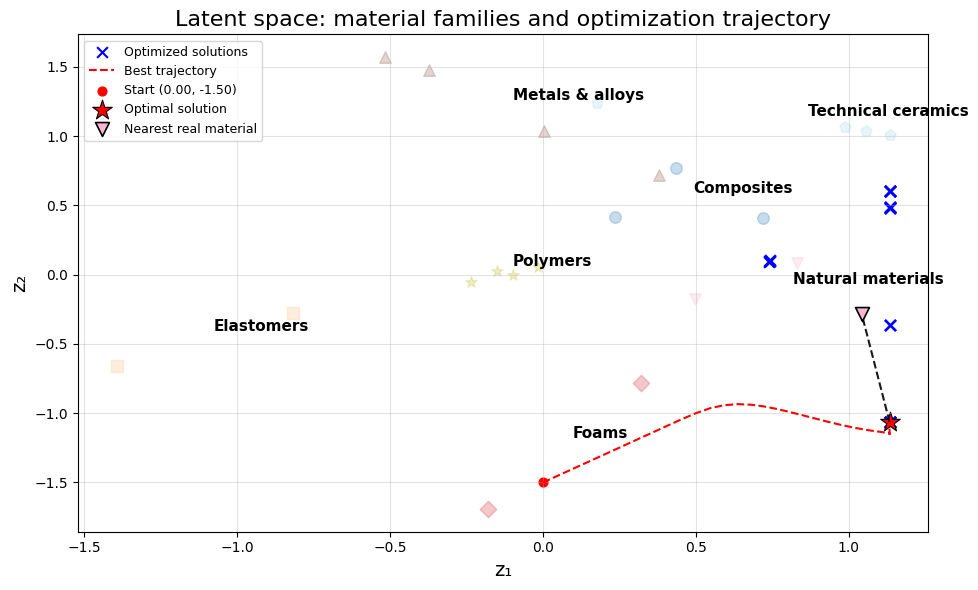


=== Nearest real material to optimized solution (latent space) ===
Material: Softwood pine
Family: Natural materials
Latent coordinates of optimal solution: (1.134, -1.063)
Latent coordinates of nearest material: (1.043, -0.285)
Euclidean distance in latent space: d = 0.78329


In [85]:
# ============================================================
# Latent space visualization with families + optimization path
# ============================================================

z_real = z_train.detach().cpu().numpy()

# --- pull arrays ---
if hasattr(dataIdentifier, "loc"):
    materials_col = dataIdentifier["material"].to_numpy()
    family_col    = dataIdentifier["family"].to_numpy()
else:
    materials_col = np.asarray(dataIdentifier["material"])
    family_col    = np.asarray(dataIdentifier["family"])

families = np.unique(family_col)

# --- colors for families ---
fam_colors = cm.tab20(np.linspace(0, 1, max(len(families), 3)))
fam_to_color = {fam: fam_colors[i % len(fam_colors)] for i, fam in enumerate(families)}

# --- markers ---
mrkrSet = ['o','s','D','^','v','*','p','h','+','x']

plt.figure(figsize=(10,6))

# ============================================================
# Plot materials grouped by family
# ============================================================

for i, fam in enumerate(families):

    idxs = np.where(family_col == fam)[0]
    points = z_real[idxs]

    plt.scatter(
        points[:,0], points[:,1],
        c=[fam_to_color[fam]],
        marker=mrkrSet[i % len(mrkrSet)],
        alpha=0.25,
        s=70
    )

    # label family at centroid
    centroid = np.mean(points, axis=0)

    plt.annotate(
        str(fam),
        (centroid[0], centroid[1]),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# Plot optimization results
# ============================================================

z_opt = np.array([r["z"] for r in results])

plt.scatter(
    z_opt[:,0], z_opt[:,1],
    c="blue",
    marker="x",
    s=60,
    label="Optimized solutions"
)

# --- best trajectory ---
best_path = np.asarray(best["z_path"])

plt.plot(
    best_path[:,0],
    best_path[:,1],
    "--",
    c="red",
    linewidth=1.5,
    label="Best trajectory"
)

# start point
start_point = best_path[0]

plt.scatter(
    start_point[0],
    start_point[1],
    s=40,
    marker="o",
    c="red",
    edgecolors="red",
    label=f"Start ({start_point[0]:.2f}, {start_point[1]:.2f})"
)

# optimal solution
z_star = np.asarray(best["z"])

plt.scatter(
    z_star[0],
    z_star[1],
    s=220,
    marker="*",
    c="red",
    edgecolors="k",
    linewidths=0.8,
    label="Optimal solution"
)

# ============================================================
# Nearest real material in latent space
# ============================================================

distances = np.linalg.norm(z_real - z_star, axis=1)

i_nn = np.argmin(distances)
z_nn = z_real[i_nn]
d_nn = distances[i_nn]

# find family of nearest material
fam_nn = family_col[i_nn]

# same color and marker as the family
color_nn = fam_to_color[fam_nn]
marker_nn = mrkrSet[list(families).index(fam_nn) % len(mrkrSet)]

plt.scatter(
    z_nn[0], z_nn[1],
    c=[color_nn],
    marker=marker_nn,
    s=100,
    alpha=1.0,
    edgecolors="black",
    linewidths=1.2,
    zorder=5,
    label="Nearest real material"
)

# =========================
# NEW: draw segment + annotate distance on the plot
# =========================
plt.plot(
    [z_star[0], z_nn[0]],
    [z_star[1], z_nn[1]],
    linestyle="--",
    color="black",
    linewidth=1.5,
    alpha=0.9
)

midpoint = 0.5 * (z_star + z_nn)
#plt.annotate(
#    fr"$d={d_nn:.3f}$",
#    (midpoint[0], midpoint[1]),
#    textcoords="offset points",
#    xytext=(8, 8),
#   ha="left",
#    va="bottom",
#    fontsize=11,
#    fontweight="bold",
#    color="black"
#)

# ============================================================

plt.xlabel("z₁", fontsize=14)
plt.ylabel("z₂", fontsize=14)

plt.title("Latent space: material families and optimization trajectory", fontsize=16)

plt.grid(True, alpha=0.35)

plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# Print distance information
# ============================================================

print("\n=== Nearest real material to optimized solution (latent space) ===")
print(f"Material: {materials_col[i_nn]}")
print(f"Family: {family_col[i_nn]}")
print(f"Latent coordinates of optimal solution: ({z_star[0]:.3f}, {z_star[1]:.3f})")
print(f"Latent coordinates of nearest material: ({z_nn[0]:.3f}, {z_nn[1]:.3f})")
print(f"Euclidean distance in latent space: d = {d_nn:.5f}")

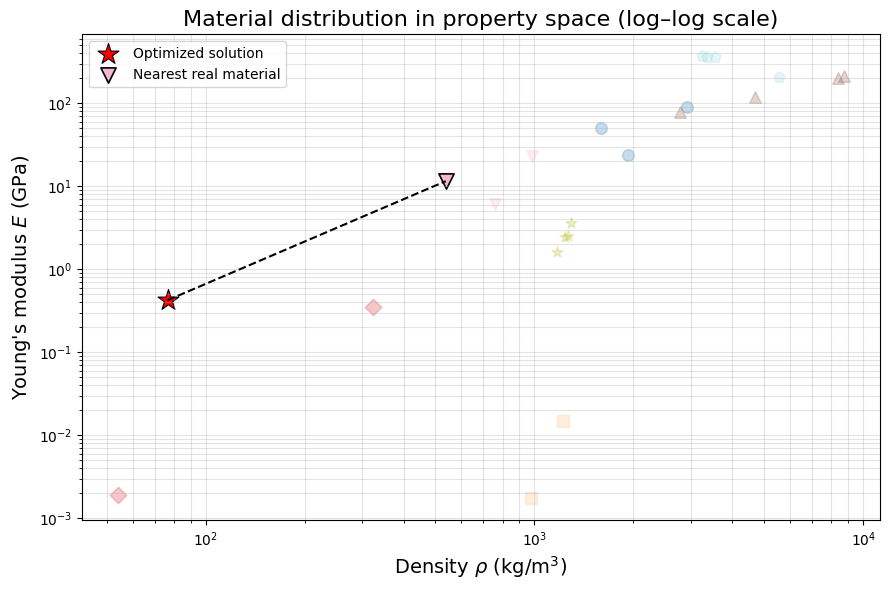

In [86]:
# ============================================================
# Ashby-style plot in property space (log-log scale)
# ============================================================

# reconstruct rho and E for all materials
rho_all = []
E_all = []

for i in range(len(z_real)):
    rho_i, E_i, _ = decode_rho_E(z_train[i:i+1])
    rho_all.append(float(rho_i))
    E_all.append(float(E_i))

rho_all = np.array(rho_all)
E_all = np.array(E_all)

# optimized properties
rho_star = best["rho"]
E_star = best["E"]

# nearest real material properties
rho_nn = rho_all[i_nn]
E_nn = E_all[i_nn]

plt.figure(figsize=(9,6))

# ============================================================
# plot materials by family
# ============================================================

for i, fam in enumerate(families):

    idxs = np.where(family_col == fam)[0]

    plt.scatter(
        rho_all[idxs],
        E_all[idxs],
        c=[fam_to_color[fam]],
        marker=mrkrSet[i % len(mrkrSet)],
        alpha=0.25,
        s=70
    )

# ============================================================
# optimized solution
# ============================================================

plt.scatter(
    rho_star,
    E_star,
    marker="*",
    c="red",
    s=250,
    edgecolors="black",
    linewidths=0.8,
    label="Optimized solution"
)

# ============================================================
# nearest real material
# ============================================================

fam_nn = family_col[i_nn]
color_nn = fam_to_color[fam_nn]
marker_nn = mrkrSet[list(families).index(fam_nn) % len(mrkrSet)]

plt.scatter(
    rho_nn,
    E_nn,
    c=[color_nn],
    marker=marker_nn,
    s=120,
    alpha=1,
    edgecolors="black",
    linewidths=1.2,
    label="Nearest real material"
)

# distance line
plt.plot(
    [rho_star, rho_nn],
    [E_star, E_nn],
    "--",
    c="black",
    linewidth=1.5
)

# ============================================================

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Density $\rho$ (kg/m$^3$)", fontsize=14)
plt.ylabel(r"Young's modulus $E$ (GPa)", fontsize=14)

plt.title("Material distribution in property space (log–log scale)", fontsize=16)

plt.grid(True, which="both", alpha=0.35)

plt.legend()

plt.tight_layout()
plt.show()

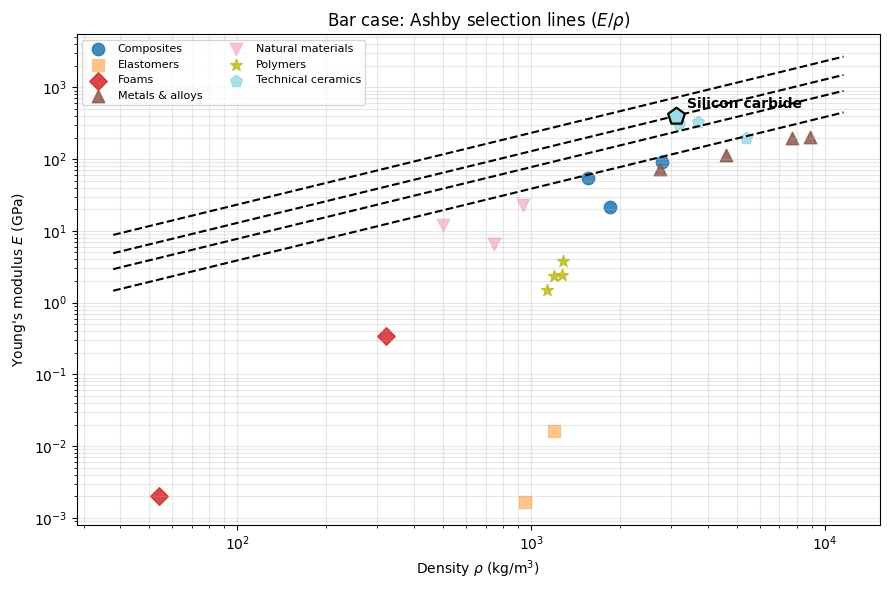

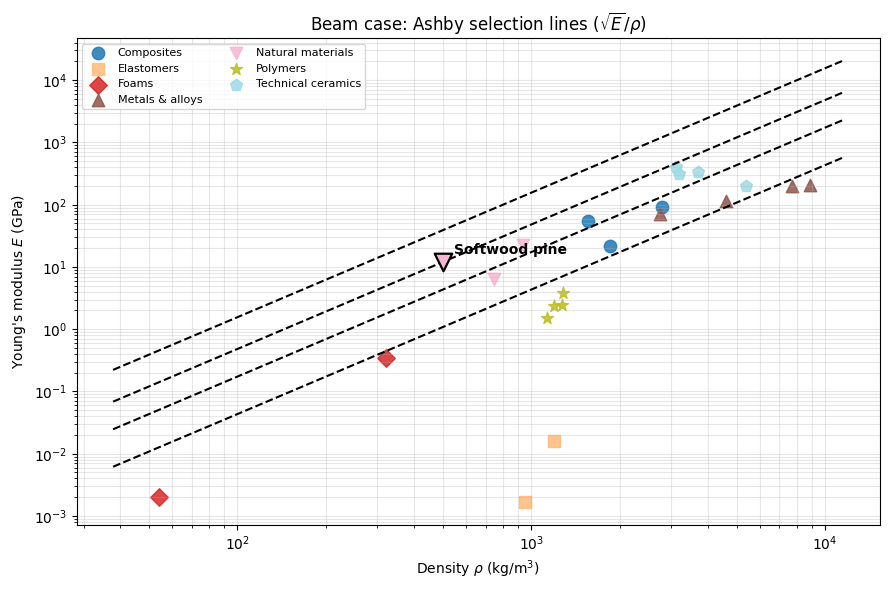

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load your Granta/Ashby table
# =========================
xlsx_path = "./ashby_from_granta_selection3.xlsx"
df = pd.read_excel(xlsx_path)

rho = df["rho"].to_numpy(dtype=float)
E   = df["E"].to_numpy(dtype=float)
fam = df["Family"].astype(str).to_numpy()
mat = df["material"].astype(str).to_numpy()

# =========================
# Ashby indices
# =========================
M_bar  = E / rho
M_beam = np.sqrt(E) / rho

# best materials (first material "touched" by sliding the selection line)
i_bar  = int(np.argmax(M_bar))
i_beam = int(np.argmax(M_beam))

Mbar_ref  = float(M_bar[i_bar])
Mbeam_ref = float(M_beam[i_beam])

# =========================
# Family colors + markers
# =========================
families = np.unique(fam)
cmap = plt.get_cmap("tab20")
colors = cmap(np.linspace(0, 1, len(families)))
fam_to_color = {f: colors[i] for i, f in enumerate(families)}

mrkrSet = ['o','s','D','^','v','*','p','h','+','x']
fam_to_marker = {f: mrkrSet[i % len(mrkrSet)] for i, f in enumerate(families)}

# rho range for Ashby lines
rho_line = np.logspace(np.log10(rho.min()*0.7), np.log10(rho.max()*1.3), 400)
multipliers = [0.3, 0.6, 1.0, 1.8]

# =====================================================
# BAR CASE
# =====================================================
plt.figure(figsize=(9,6))

# plot materials by family with family marker
for f in families:
    idx = np.where(fam == f)[0]
    plt.scatter(
        rho[idx], E[idx],
        s=80,
        alpha=0.85,
        color=fam_to_color[f],
        marker=fam_to_marker[f],
        label=f
    )

# Ashby lines (black dashed)
for m in multipliers:
    E_line = (m * Mbar_ref) * rho_line
    plt.plot(rho_line, E_line, color="black", linestyle="--", linewidth=1.5)

# highlight best material (KEEP its family marker/color)
f_best = fam[i_bar]
plt.scatter(
    rho[i_bar], E[i_bar],
    s=160,                         # bigger
    color=fam_to_color[f_best],
    marker=fam_to_marker[f_best],  # same shape as family
    edgecolors="black",
    linewidths=1.6,
    zorder=6
)

plt.annotate(
    mat[i_bar],
    (rho[i_bar], E[i_bar]),
    textcoords="offset points",
    xytext=(8, 6),
    fontsize=10,
    fontweight="bold"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Density $\rho$ (kg/m$^3$)")
plt.ylabel(r"Young's modulus $E$ (GPa)")
plt.title("Bar case: Ashby selection lines ($E/\\rho$)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


# =====================================================
# BEAM CASE
# =====================================================
plt.figure(figsize=(9,6))

for f in families:
    idx = np.where(fam == f)[0]
    plt.scatter(
        rho[idx], E[idx],
        s=80,
        alpha=0.85,
        color=fam_to_color[f],
        marker=fam_to_marker[f],
        label=f
    )

# Ashby lines (black dashed)
for m in multipliers:
    E_line = (m * Mbeam_ref * rho_line) ** 2
    plt.plot(rho_line, E_line, color="black", linestyle="--", linewidth=1.5)

# highlight best material (KEEP its family marker/color)
f_best = fam[i_beam]
plt.scatter(
    rho[i_beam], E[i_beam],
    s=160,
    color=fam_to_color[f_best],
    marker=fam_to_marker[f_best],
    edgecolors="black",
    linewidths=1.6,
    zorder=6
)

plt.annotate(
    mat[i_beam],
    (rho[i_beam], E[i_beam]),
    textcoords="offset points",
    xytext=(8, 6),
    fontsize=10,
    fontweight="bold"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Density $\rho$ (kg/m$^3$)")
plt.ylabel(r"Young's modulus $E$ (GPa)")
plt.title("Beam case: Ashby selection lines ($\\sqrt{E}/\\rho$)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Comment on the optimization result

As expected, the optimized solution in the latent space lies close to the **woods** material family.  
This result is consistent with Ashby material selection theory for stiffness-limited, weight-critical structures, where materials with a high ratio  **M = sqrt(E) / rho** are preferred.

The fact that the VAE-based latent optimization naturally converges toward the wood region, without explicitly encoding material classes, indicates that:

- the VAE has learned a physically meaningful latent representation of the material space, and  
- the gradient-based optimization procedure is able to recover known optimal material choices for this problem.

Therefore, the combined **VAE + optimization** framework is validated for this material selection task.

